In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import numpy as np
from hidten.tf import TFHMM

from learnMSA.util import visualize

2026-03-20 15:02:04.257070: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774015324.273732 3987453 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774015324.278837 3987453 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774015324.291964 3987453 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774015324.291977 3987453 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774015324.291978 3987453 computation_placer.cc:177] computation placer alr

In [2]:
hmm = TFHMM(states=2, heads=3)

hmm.transitioner.allow = [
    (0, 1), (1, 0), (0, 1, 1),
]
hmm.transitioner.initializer = np.exp([0, 0, 0, 1, 1, 1, 2])
hmm.emitter[0].initializer = np.exp([
    0, 1, 1, 0,
    0, 1, 1, 1,
    0, 1, 1, 2,
])

hmm.build((2, ))

2026-03-20 15:02:06.628006: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
2026-03-20 15:02:06.628026: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:167] env: CUDA_VISIBLE_DEVICES="-1"
2026-03-20 15:02:06.628031: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:170] CUDA_VISIBLE_DEVICES is set to -1 - this hides all GPUs from CUDA
2026-03-20 15:02:06.628034: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:178] verbose logging is disabled. Rerun with verbose logging (usually --v=1 or --vmodule=cuda_diagnostics=1) to get more diagnostic output from this module
2026-03-20 15:02:06.628038: I external/local_xla/xla/stream_executor/cuda/cuda_diagnostics.cc:183] retrieving CUDA diagnostic information for host: powergreif
2026-03-20 15:02:06.628041: I external/local_xla/xla/stream_executor/cuda/cu

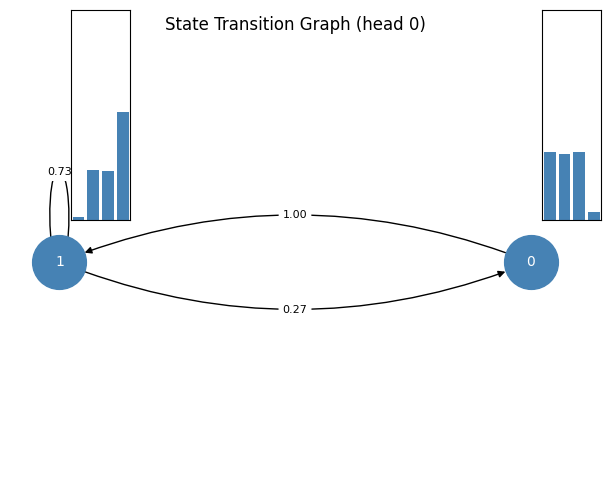

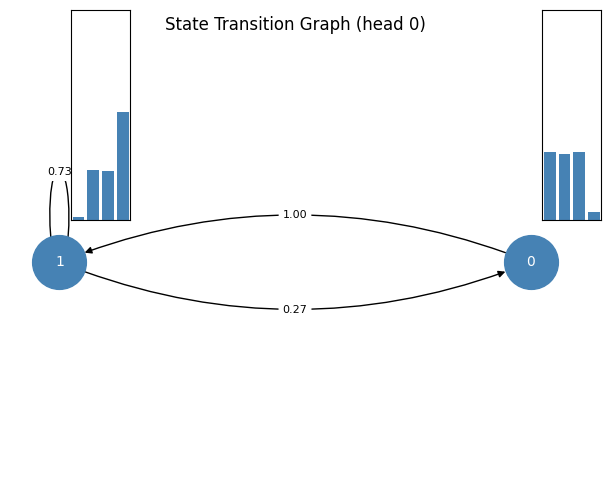

In [3]:
_,pos = visualize.plot_transition_graph(hmm, self_loop_connectionstyle="arc3,rad=0.4")
visualize.plot_emissions(hmm, pos=pos, emitter_index=0)

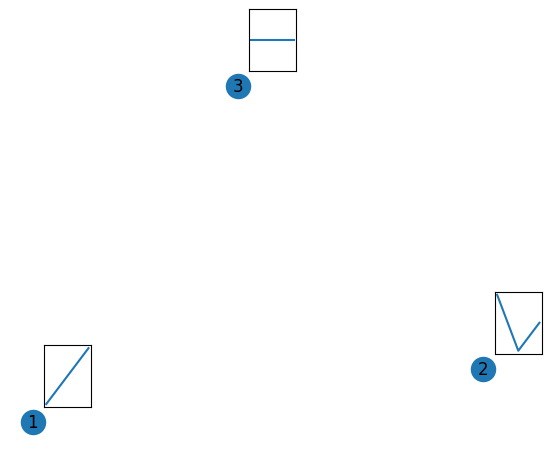

In [4]:
import networkx as nx
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

G = nx.Graph()
G.add_nodes_from([1, 2, 3])

node_data = {
    1: [1, 2, 3],
    2: [3, 1, 2],
    3: [2, 2, 2]
}

pos = nx.spring_layout(G)

fig, ax = plt.subplots()
nx.draw(G, pos, ax=ax, with_labels=True)

offset = (0.05, 0.05)

for node, (x, y) in pos.items():
    # Create inset anchored at data coordinates
    axins = inset_axes(
        ax,
        width="100%", height="100%",              # fill the bbox
        bbox_to_anchor=(x+offset[0], y+offset[1], 0.2, 0.2),         # (x, y, width, height) in data coords
        bbox_transform=ax.transData,
        loc='center',
        borderpad=0
    )

    # Apply a consistent offset (in points)
    axins.set_anchor('NW')  # optional anchor direction
    axins.plot(node_data[node])
    axins.set_xticks([])
    axins.set_yticks([])

plt.show()